#Preparation

In [ ]:
!pip install praat-parselmouth librosa soundfile tqdm --quiet

import os, shutil, warnings
import numpy as np
import pandas as pd
import librosa
import parselmouth
from parselmouth.praat import call
from tqdm import tqdm
from google.colab import drive

warnings.filterwarnings("ignore")
print("✅ Library siap.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 44.1 MB/s eta 0:00:00
✅ Library siap.


In [ ]:
drive.mount('/content/drive')

AUDIO_ROOT  = '/content/drive/MyDrive/TADATA/BigData'
OUTPUT_CSV  = '/content/drive/MyDrive/TADATA/hasil_acoustic_filter.csv'
OUTPUT_ROOT = '/content/drive/MyDrive/TADATA/FinalData/BigData_Filtered'

VALID_EMOTIONS = ['Marah', 'Jijik', 'Takut', 'Netral', 'Sedih', 'Bahagia']
PROB_FOLDERS   = ['prob1', 'prob0_5_to_1']   # prob1 = prioritas
AUDIO_EXT      = ('.wav', '.mp3', '.flac', '.ogg', '.m4a')

print("\n📁 Verifikasi folder:")
total = 0
for em in VALID_EMOTIONS:
    for p in PROB_FOLDERS:
        path = os.path.join(AUDIO_ROOT, em, p)
        n    = len([f for f in os.listdir(path)
                    if f.lower().endswith(AUDIO_EXT)]) if os.path.isdir(path) else 0
        flag = "✅" if os.path.isdir(path) else "❌"
        total += n
        print(f"   {flag}  {em}/{p}/  → {n} file")
print(f"\n   Total keseluruhan : {total} file")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📁 Verifikasi folder:
   ✅  Marah/prob1/  → 517 file
   ✅  Marah/prob0_5_to_1/  → 143 file
   ✅  Jijik/prob1/  → 5 file
   ✅  Jijik/prob0_5_to_1/  → 11 file
   ✅  Takut/prob1/  → 150 file
   ✅  Takut/prob0_5_to_1/  → 191 file
   ✅  Netral/prob1/  → 1435 file
   ✅  Netral/prob0_5_to_1/  → 191 file
   ✅  Sedih/prob1/  → 454 file
   ✅  Sedih/prob0_5_to_1/  → 75 file

   Total keseluruhan : 3172 file


#Process

In [ ]:
EMOTION_PARAMS = {

    'Netral': {
        # Pembeda utama: f0_mean TERENDAH (mean=157.81 vs emosi lain 214-310)
        # BATAS KERAS dari data aktual: semua Netral punya f0_mean ≤ 214.46
        'f0_mean': {'min': None, 'max': 215,   'weight': 5},
        'f0_std':  {'min': None, 'max': 52,    'weight': 3},
        'jitter':  {'min': None, 'max': 0.035, 'weight': 2},
        'shimmer': {'min': None, 'max': 0.17,  'weight': 1},
    },

    'Marah': {
        # Pembeda utama: energy_rms TERTINGGI (mean=0.1191 vs lain 0.07-0.08)
        # BATAS KERAS dari data aktual: semua Marah punya energy ≥ 0.0852
        'energy_rms':  {'min': 0.085, 'max': None,  'weight': 5},
        'f0_mean':     {'min': 215,   'max': None,  'weight': 2},
        'speech_rate': {'min': 7.0,   'max': None,  'weight': 2},
    },

    'Takut': {
        # Pembeda utama: f0_std TERTINGGI (mean=89.61 vs Sedih 35.13)
        # BATAS KERAS dari data aktual: semua Takut punya f0_std ≥ 60.48
        # Jitter dan Shimmer juga tertinggi → suara bergetar/tremor
        'f0_std':     {'min': 60,    'max': None,  'weight': 5},
        'jitter':     {'min': 0.028, 'max': None,  'weight': 3},
        'shimmer':    {'min': 0.14,  'max': None,  'weight': 2},
        'energy_rms': {'min': None,  'max': 0.086, 'weight': 1},
    },

    'Jijik': {
        # Pembeda utama: f0_mean TERTINGGI + spectral_centroid TERTINGGI
        # BATAS KERAS dari data aktual:
        #   semua Jijik punya f0_mean ≥ 256.01
        #   semua Jijik punya spectral_centroid ≥ 1460.10
        'f0_mean':           {'min': 256,  'max': None,  'weight': 4},
        'spectral_centroid': {'min': 1460, 'max': None,  'weight': 4},
        'energy_rms':        {'min': None, 'max': 0.088, 'weight': 2},
    },

    'Sedih': {
        # Posisi tengah: pitch medium, energi rendah,
        # pitch stabil (f0_std rendah), spectral centroid terendah
        'f0_mean':           {'min': 180,  'max': 260,   'weight': 2},
        'f0_std':            {'min': None, 'max': 57,    'weight': 3},
        'energy_rms':        {'min': None, 'max': 0.087, 'weight': 2},
        'spectral_centroid': {'min': None, 'max': 1490,  'weight': 2},
    },

    'Bahagia': {
        # ── Profil akustik "joy / elation" — rujukan Banse & Scherer
        #    (1996) dan Juslin & Laukka (2003): nada TINGGI, rentang
        #    nada LEBAR, tempo CEPAT, spektrum CERAH, namun suara
        #    tetap relatif HALUS (perturbasi rendah).
        #
        # Pembeda utama dari emosi lain:
        #   • vs Takut → f0_std sama-sama tinggi, TAPI Bahagia jitter
        #     RENDAH (suara mantap/cerah); Takut jitter TINGGI (tremor).
        #   • vs Jijik → sama-sama f0_mean & spectral_centroid tinggi,
        #     TAPI Bahagia f0_std LEBAR (melodik); Jijik cenderung datar.
        #   • vs Netral/Sedih → f0_mean & f0_std Bahagia jauh lebih tinggi.
        #
        # CATATAN: ambang di bawah diturunkan dari literatur + posisi
        # relatif thd 5 emosi lama. Sangat disarankan dikalibrasi ulang
        # begitu data Bahagia aktual sudah tersedia.
        'f0_mean':           {'min': 220,   'max': None,  'weight': 4},
        'f0_std':            {'min': 55,    'max': None,  'weight': 4},
        'speech_rate':       {'min': 6.5,   'max': None,  'weight': 3},
        'spectral_centroid': {'min': 1500,  'max': None,  'weight': 2},
        'jitter':            {'min': None,  'max': 0.030, 'weight': 2},
    },
}


In [ ]:
def extract_features(filepath):
    """
    Ekstrak 7 fitur akustik dari file audio.
    Menggunakan Praat (via parselmouth) untuk Pitch, Jitter, Shimmer.
    Menggunakan Librosa untuk Energy, Speech Rate, Spectral Centroid.
    """
    try:
        y, sr = librosa.load(filepath, sr=16000, mono=True)
        duration = librosa.get_duration(y=y, sr=sr)
        if duration < 0.3:
            return None

        # ── Pitch / F0 via Praat ──
        sound   = parselmouth.Sound(filepath)
        pitch   = call(sound, "To Pitch", 0.0, 75, 500)
        f0_vals = pitch.selected_array['frequency']
        f0_vals = f0_vals[f0_vals > 0]
        f0_mean = float(np.mean(f0_vals)) if len(f0_vals) >= 5 else 0.0
        f0_std  = float(np.std(f0_vals))  if len(f0_vals) >= 5 else 0.0

        # ── Jitter & Shimmer via Praat ──
        try:
            pp      = call(sound, "To PointProcess (periodic, cc)", 75, 500)
            jitter  = call(pp, "Get jitter (local)",
                           0, 0, 0.0001, 0.02, 1.3)
            shimmer = call([sound, pp], "Get shimmer (local)",
                           0, 0, 0.0001, 0.02, 1.3, 1.6)
        except Exception:
            jitter, shimmer = 0.0, 0.0

        # ── Energy / RMS via Librosa ──
        energy_rms = float(np.sqrt(np.mean(y ** 2)))

        # ── Speech Rate via Onset Detection ──
        onset_env   = librosa.onset.onset_strength(y=y, sr=sr)
        onsets      = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)
        speech_rate = len(onsets) / duration if duration > 0 else 0.0

        # ── Spectral Centroid ──
        spec_centroid = float(np.mean(
            librosa.feature.spectral_centroid(y=y, sr=sr)))

        return {
            'f0_mean':           round(f0_mean,       2),
            'f0_std':            round(f0_std,        2),
            'energy_rms':        round(energy_rms,    5),
            'speech_rate':       round(speech_rate,   3),
            'jitter':            round(jitter,        5),
            'shimmer':           round(shimmer,       5),
            'spectral_centroid': round(spec_centroid, 1),
            'duration_sec':      round(duration,      3),
        }

    except Exception as e:
        print(f"  ⚠️  Error [{os.path.basename(filepath)}]: {e}")
        return None

In [ ]:
def score_emotion(features):
    """
    Hitung skor tiap emosi berdasarkan parameter threshold.
    Skor = matched_weight / total_weight (range 0–1)
    File diarahkan ke emosi dengan skor tertinggi.
    """
    scores = {}
    for emotion, params in EMOTION_PARAMS.items():
        total_w, matched_w = 0, 0
        for feat, cfg in params.items():
            val = features.get(feat)
            if val is None or (isinstance(val, float) and np.isnan(val)):
                continue
            w = cfg['weight']
            total_w += w
            lo = cfg.get('min')
            hi = cfg.get('max')
            in_range = (lo is None or val >= lo) and \
                       (hi is None or val <= hi)
            if in_range:
                matched_w += w
        scores[emotion] = round(matched_w / total_w, 3) \
                          if total_w > 0 else 0

    best = max(scores, key=scores.get)
    return scores, best

In [ ]:
def scan_and_analyze():
    records    = []
    seen_files = set()

    print("\n" + "="*60)
    print("SCAN AUDIO — Prioritas: prob1 → prob0_5_to_1")
    print("="*60)

    for emotion_label in VALID_EMOTIONS:
        print(f"\n📂 [{emotion_label.upper()}]")

        for prob_tag in PROB_FOLDERS:
            folder = os.path.join(AUDIO_ROOT, emotion_label, prob_tag)
            if not os.path.isdir(folder):
                print(f"   ⚠️  Skip — tidak ada: {prob_tag}")
                continue

            files = sorted([f for f in os.listdir(folder)
                            if f.lower().endswith(AUDIO_EXT)])
            print(f"   [{prob_tag}] {len(files)} file — proses...")

            for fname in tqdm(files, desc=f"    {prob_tag}", leave=False):
                dedup_key = f"{emotion_label}::{fname}"
                if dedup_key in seen_files:
                    continue
                seen_files.add(dedup_key)

                fpath    = os.path.join(folder, fname)
                features = extract_features(fpath)

                base = {
                    'filename':    fname,
                    'filepath':    fpath,
                    'label_asli':  emotion_label,
                    'prob_source': prob_tag,
                }

                if features is None:
                    base.update({
                        'label_akustik': 'ERROR',
                        'status':        'SKIP',
                        **{k: None for k in ['f0_mean','f0_std','energy_rms',
                                             'speech_rate','jitter','shimmer',
                                             'spectral_centroid','duration_sec']},
                        **{f'skor_{em}': None for em in VALID_EMOTIONS},
                    })
                    records.append(base)
                    continue

                scores, best = score_emotion(features)
                status = 'OK' if best == emotion_label else 'RELABEL'

                base.update({
                    'label_akustik': best,
                    'status':        status,
                    **features,
                    **{f'skor_{em}': scores[em] for em in VALID_EMOTIONS},
                })
                records.append(base)

    df = pd.DataFrame(records)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✅ Scan selesai! CSV → {OUTPUT_CSV}")
    print(f"   Total file diproses: {len(df)}")
    return df


df = scan_and_analyze()


SCAN AUDIO — Prioritas: prob1 → prob0_5_to_1

📂 [MARAH]
   [prob1] 517 file — proses...


   [prob0_5_to_1] 143 file — proses...



📂 [JIJIK]
   [prob1] 5 file — proses...


   [prob0_5_to_1] 11 file — proses...



📂 [TAKUT]
   [prob1] 150 file — proses...


...


📂 [NETRAL]
   [prob1] 1435 file — proses...


   [prob0_5_to_1] 191 file — proses...



📂 [SEDIH]
   [prob1] 454 file — proses...


   [prob0_5_to_1] 75 file — proses...



✅ Scan selesai! CSV → /content/drive/MyDrive/TADATA/hasil_acoustic_filter.csv
   Total file diproses: 3172


In [ ]:
# ── JUMLAH DATA PER EMOSI SETELAH ACOUSTIC FILTER ──────────────
# Dijalankan SEBELUM Greedy Top-N. Menampilkan distribusi hasil
# relabeling berbasis fitur akustik (kolom 'label_akustik'),
# dibandingkan label awal ('label_asli'), berikut rincian OK/RELABEL.

print("\n" + "="*60)
print("DISTRIBUSI DATA SETELAH ACOUSTIC FILTER")
print("="*60)

# Hanya file valid (lolos ekstraksi: OK atau RELABEL)
valid_after = df[df['status'].isin(['OK', 'RELABEL'])].copy()
valid_after = valid_after[valid_after['label_akustik'].isin(VALID_EMOTIONS)]

# ── Tabel: Sebelum (label_asli) vs Sesudah (label_akustik) ──
print(f"\n{'Emosi':<10}{'Sebelum':>10}{'Sesudah':>10}{'Selisih':>10}")
print("-"*40)
tot_before = tot_after = 0
for em in VALID_EMOTIONS:
    n_before = int((valid_after['label_asli']    == em).sum())
    n_after  = int((valid_after['label_akustik'] == em).sum())
    delta    = n_after - n_before
    sign     = f"+{delta}" if delta > 0 else f"{delta}"
    print(f"{em:<10}{n_before:>10}{n_after:>10}{sign:>10}")
    tot_before += n_before
    tot_after  += n_after
print("-"*40)
print(f"{'TOTAL':<10}{tot_before:>10}{tot_after:>10}")

# ── Rincian status filter ──
n_ok      = int((valid_after['status'] == 'OK').sum())
n_relabel = int((valid_after['status'] == 'RELABEL').sum())
n_valid   = len(valid_after)
print(f"\nStatus filter (total {n_valid} file valid):")
print(f"   OK (label tetap)       : {n_ok:>5}  ({n_ok/n_valid*100:.1f}%)")
print(f"   RELABEL (pindah label) : {n_relabel:>5}  ({n_relabel/n_valid*100:.1f}%)")

# ── Jumlah akhir per emosi SETELAH filter (dengan bar) ──
print(f"\nJumlah per emosi setelah Acoustic Filter:")
for em in VALID_EMOTIONS:
    n   = int((valid_after['label_akustik'] == em).sum())
    bar = '#' * (n // 10)
    print(f"   {em:<10}: {n:>5}  {bar}")


In [ ]:
TARGET = 500

valid_df = df[df['status'].isin(['OK','RELABEL'])].copy()
valid_df = valid_df[valid_df['label_akustik'].isin(VALID_EMOTIONS)].copy()

# Hitung distribusi saat ini
print(f"\n{'='*55}")
print(f"GREEDY TOP-{TARGET} SELECTION")
print(f"{'='*55}")
print(f"\nDistribusi sebelum seleksi:")
for em in VALID_EMOTIONS:
    n = (valid_df['label_akustik']==em).sum()
    print(f"   {em:<8}: {n:>4}")

# Urutan prioritas: dari paling sedikit
priority = sorted(VALID_EMOTIONS,
                  key=lambda c: (valid_df['label_akustik']==c).sum())
print(f"\nUrutan prioritas: {' → '.join(priority)}\n")

used_indices  = set()
selected_dfs  = {}

for cls in priority:
    sc        = f'skor_{cls}'
    available = valid_df[~valid_df.index.isin(used_indices)].copy()
    selected  = available.nlargest(TARGET, sc).copy()
    selected['label_final'] = cls

    used_indices.update(selected.index.tolist())
    selected_dfs[cls] = selected

    min_s     = selected[sc].min()
    max_s     = selected[sc].max()
    konsisten = (selected['label_akustik']==cls).sum()
    pindah    = TARGET - konsisten

    print(f"✅ {cls:<8}: {len(selected)} file dipilih")
    print(f"   Skor         : {min_s:.3f} – {max_s:.3f}")
    print(f"   Konsisten    : {konsisten} | Pindah dari label lain: {pindah}\n")

df_final = pd.concat(selected_dfs.values(), ignore_index=True)

print(f"{'='*55}")
print(f"Distribusi FINAL (setelah Greedy Top-{TARGET}):")
for cls in VALID_EMOTIONS:
    n   = (df_final['label_final']==cls).sum()
    bar = '█' * (n // 5)
    print(f"   ✅ {cls:<8}: {n}  {bar}")
print(f"\n   Total: {len(df_final)} file")



GREEDY TOP-250 SELECTION

Distribusi sebelum seleksi:
   Marah   :  876
   Jijik   :  308
   Takut   :  327
   Netral  : 1383
   Sedih   :  278

Urutan prioritas: Sedih → Jijik → Takut → Marah → Netral

✅ Sedih   : 250 file dipilih
   Skor         : 0.778 – 1.000
   Konsisten    : 102 | Pindah dari label lain: 148

✅ Jijik   : 250 file dipilih
   Skor         : 0.800 – 1.000
   Konsisten    : 184 | Pindah dari label lain: 66

✅ Takut   : 250 file dipilih
   Skor         : 0.909 – 1.000
   Konsisten    : 215 | Pindah dari label lain: 35

✅ Marah   : 250 file dipilih
   Skor         : 1.000 – 1.000
   Konsisten    : 250 | Pindah dari label lain: 0

✅ Netral  : 250 file dipilih
   Skor         : 1.000 – 1.000
   Konsisten    : 250 | Pindah dari label lain: 0

Distribusi FINAL (setelah Greedy Top-250):
   ✅ Marah   : 250  ██████████████████████████████████████████████████
   ✅ Jijik   : 250  ██████████████████████████████████████████████████
   ✅ Takut   : 250  ███████████████████████████

In [ ]:
df_final.to_csv(OUTPUT_CSV.replace('.csv', f'_balanced{TARGET}.csv'), index=False)
print(f"\n✅ CSV balanced → "
      f"{OUTPUT_CSV.replace('.csv', f'_balanced{TARGET}.csv')}")

# Statistik fitur per emosi setelah seleksi
print(f"\n{'='*55}")
print("STATISTIK FITUR PER EMOSI (label_final)")
print(f"{'='*55}\n")

feat_cols = ['f0_mean','f0_std','energy_rms','speech_rate',
             'jitter','shimmer','spectral_centroid']

stats = (df_final.groupby('label_final')[feat_cols]
         .agg(['mean','std','min','max'])
         .round(4))
print(stats.to_string())



✅ CSV balanced → /content/drive/MyDrive/TADATA/hasil_acoustic_filter_balanced200.csv

STATISTIK FITUR PER EMOSI (label_final)

              f0_mean                            f0_std                         energy_rms                         speech_rate                         jitter                         shimmer                         spectral_centroid                          
                 mean      std     min     max     mean      std    min     max       mean     std     min     max        mean     std    min     max    mean     std     min     max    mean     std     min     max              mean       std     min     max
label_final                                                                                                                                                                                                                                                      
Jijik        315.4198  40.3739  256.01  434.02  66.2223  26.7458  17.43  132.09     0.0797  0.0217

In [ ]:
def reorganize_files(df_selected, output_root, mode='copy'):
    """
    Salin / pindahkan file ke struktur folder berdasarkan label_final.
    mode='copy' → aman, data asli tidak berubah (DIREKOMENDASIKAN)
    mode='move' → pindah permanen
    """
    os.makedirs(output_root, exist_ok=True)
    for em in VALID_EMOTIONS:
        os.makedirs(os.path.join(output_root, em), exist_ok=True)

    moved, skipped = 0, 0

    for _, row in tqdm(df_selected.iterrows(),
                       total=len(df_selected),
                       desc="Reorganisasi"):
        src   = row.get('filepath')
        label = row.get('label_final')

        if not src or not os.path.isfile(str(src)):
            skipped += 1
            continue
        if label not in VALID_EMOTIONS:
            skipped += 1
            continue

        dst  = os.path.join(output_root, label, row['filename'])
        base, ext = os.path.splitext(dst)
        counter   = 2
        while os.path.exists(dst):
            dst = f"{base}_{counter}{ext}"
            counter += 1

        try:
            if mode == 'copy':
                shutil.copy2(src, dst)
            else:
                shutil.move(src, dst)
            moved += 1
        except Exception as e:
            print(f"  ⚠️  [{row['filename']}]: {e}")
            skipped += 1

    print(f"\n✅ Reorganisasi selesai! ({mode})")
    print(f"   Berhasil : {moved}")
    print(f"   Dilewati : {skipped}")
    print(f"\n   Distribusi folder output ({output_root}):")
    for em in VALID_EMOTIONS:
        folder = os.path.join(output_root, em)
        n      = len(os.listdir(folder)) if os.path.isdir(folder) else 0
        bar    = '█' * (n // 5)
        print(f"   {'✅' if n>=TARGET else '⚠️ '} {em:<8}: {n:>4}  {bar}")


reorganize_files(df_final, OUTPUT_ROOT, mode='copy')


Reorganisasi: 100%|██████████| 1250/1250 [00:17<00:00, 73.13it/s]


✅ Reorganisasi selesai! (copy)
   Berhasil : 1250
   Dilewati : 0

   Distribusi folder output (/content/drive/MyDrive/TADATA/FinalData/BigData_Filtered):
   ✅ Marah   :  250  ██████████████████████████████████████████████████
   ✅ Jijik   :  250  ██████████████████████████████████████████████████
   ✅ Takut   :  250  ██████████████████████████████████████████████████
   ✅ Netral  :  250  ██████████████████████████████████████████████████
   ✅ Sedih   :  250  ██████████████████████████████████████████████████


In [ ]:
print(f"""
{'='*60}
RINGKASAN AKHIR — Acoustic Filter (Revised Parameters)
{'='*60}

  Parameter Baru (dikalibrasi dari data aktual):
  ┌─ Netral  : f0_mean ≤ 215 Hz  (weight 5) ← batas keras
  │            f0_std  ≤ 52     (weight 3)
  │            jitter  ≤ 0.035  (weight 2)
  ├─ Marah   : energy  ≥ 0.085  (weight 5) ← batas keras
  │            f0_mean ≥ 215 Hz (weight 2)
  │            speech_rate ≥ 7.0 (weight 2)
  ├─ Takut   : f0_std  ≥ 60     (weight 5) ← batas keras
  │            jitter  ≥ 0.028  (weight 3)
  │            shimmer ≥ 0.14   (weight 2)
  ├─ Jijik   : f0_mean ≥ 256 Hz (weight 4) ← batas keras
  │            spectral≥ 1460 Hz (weight 4)← batas keras
  │            energy  ≤ 0.088  (weight 2)
  ├─ Sedih   : f0_mean 180-260  (weight 2)
  │            f0_std  ≤ 57     (weight 3)
  │            energy  ≤ 0.087  (weight 2)
  │            spectral≤ 1490 Hz (weight 2)
  └─ Bahagia : f0_mean ≥ 220 Hz (weight 4) ← batas keras
               f0_std  ≥ 55     (weight 4) ← batas keras
               speech_rate ≥ 6.5 (weight 3)
               spectral≥ 1500 Hz (weight 2)
               jitter  ≤ 0.030  (weight 2)

  Metode Seleksi: Greedy Top-{TARGET}
  ├─ Prioritas dari kelas paling sedikit
  └─ Setiap file hanya masuk ke 1 emosi

  Distribusi Final:
  ├─ Bahagia: {(df_final['label_final']=='Bahagia').sum()} ✅
  ├─ Jijik  : {(df_final['label_final']=='Jijik').sum()} ✅
  ├─ Marah  : {(df_final['label_final']=='Marah').sum()} ✅
  ├─ Netral : {(df_final['label_final']=='Netral').sum()} ✅
  ├─ Sedih  : {(df_final['label_final']=='Sedih').sum()} ✅
  └─ Takut  : {(df_final['label_final']=='Takut').sum()} ✅
  Total     : {len(df_final)} file

  Output:
  ├─ CSV all   : {OUTPUT_CSV}
  ├─ CSV bal   : {OUTPUT_CSV.replace('.csv', f'_balanced{TARGET}.csv')}
  └─ Folder    : {OUTPUT_ROOT}/
{'='*60}
""")



RINGKASAN AKHIR — Acoustic Filter (Revised Parameters)
 
  Parameter Baru (dikalibrasi dari data aktual):
  ┌─ Netral  : f0_mean ≤ 215 Hz  (weight 5) ← batas keras
  │            f0_std  ≤ 52     (weight 3)
  │            jitter  ≤ 0.035  (weight 2)
  ├─ Marah   : energy  ≥ 0.085  (weight 5) ← batas keras
  │            f0_mean ≥ 215 Hz (weight 2)
  │            speech_rate ≥ 7.0 (weight 2)
  ├─ Takut   : f0_std  ≥ 60     (weight 5) ← batas keras
  │            jitter  ≥ 0.028  (weight 3)
  │            shimmer ≥ 0.14   (weight 2)
  ├─ Jijik   : f0_mean ≥ 256 Hz (weight 4) ← batas keras
  │            spectral≥ 1460 Hz (weight 4)← batas keras
  │            energy  ≤ 0.088  (weight 2)
  └─ Sedih   : f0_mean 180-260  (weight 2)
               f0_std  ≤ 57     (weight 3)
               energy  ≤ 0.087  (weight 2)
               spectral≤ 1490 Hz (weight 2)
 
  Metode Seleksi: Greedy Top-250
  ├─ Prioritas dari kelas paling sedikit
  └─ Setiap file hanya masuk ke 1 emosi
 
  Distribusi F

#Visualisasi

Tahap 1 (Fleiss Kappa)    : 3172 file
Tahap 2 (Acoustic Filter) : 3172 file
Tahap 3 (Top-200 Greedy)  : 1250 file


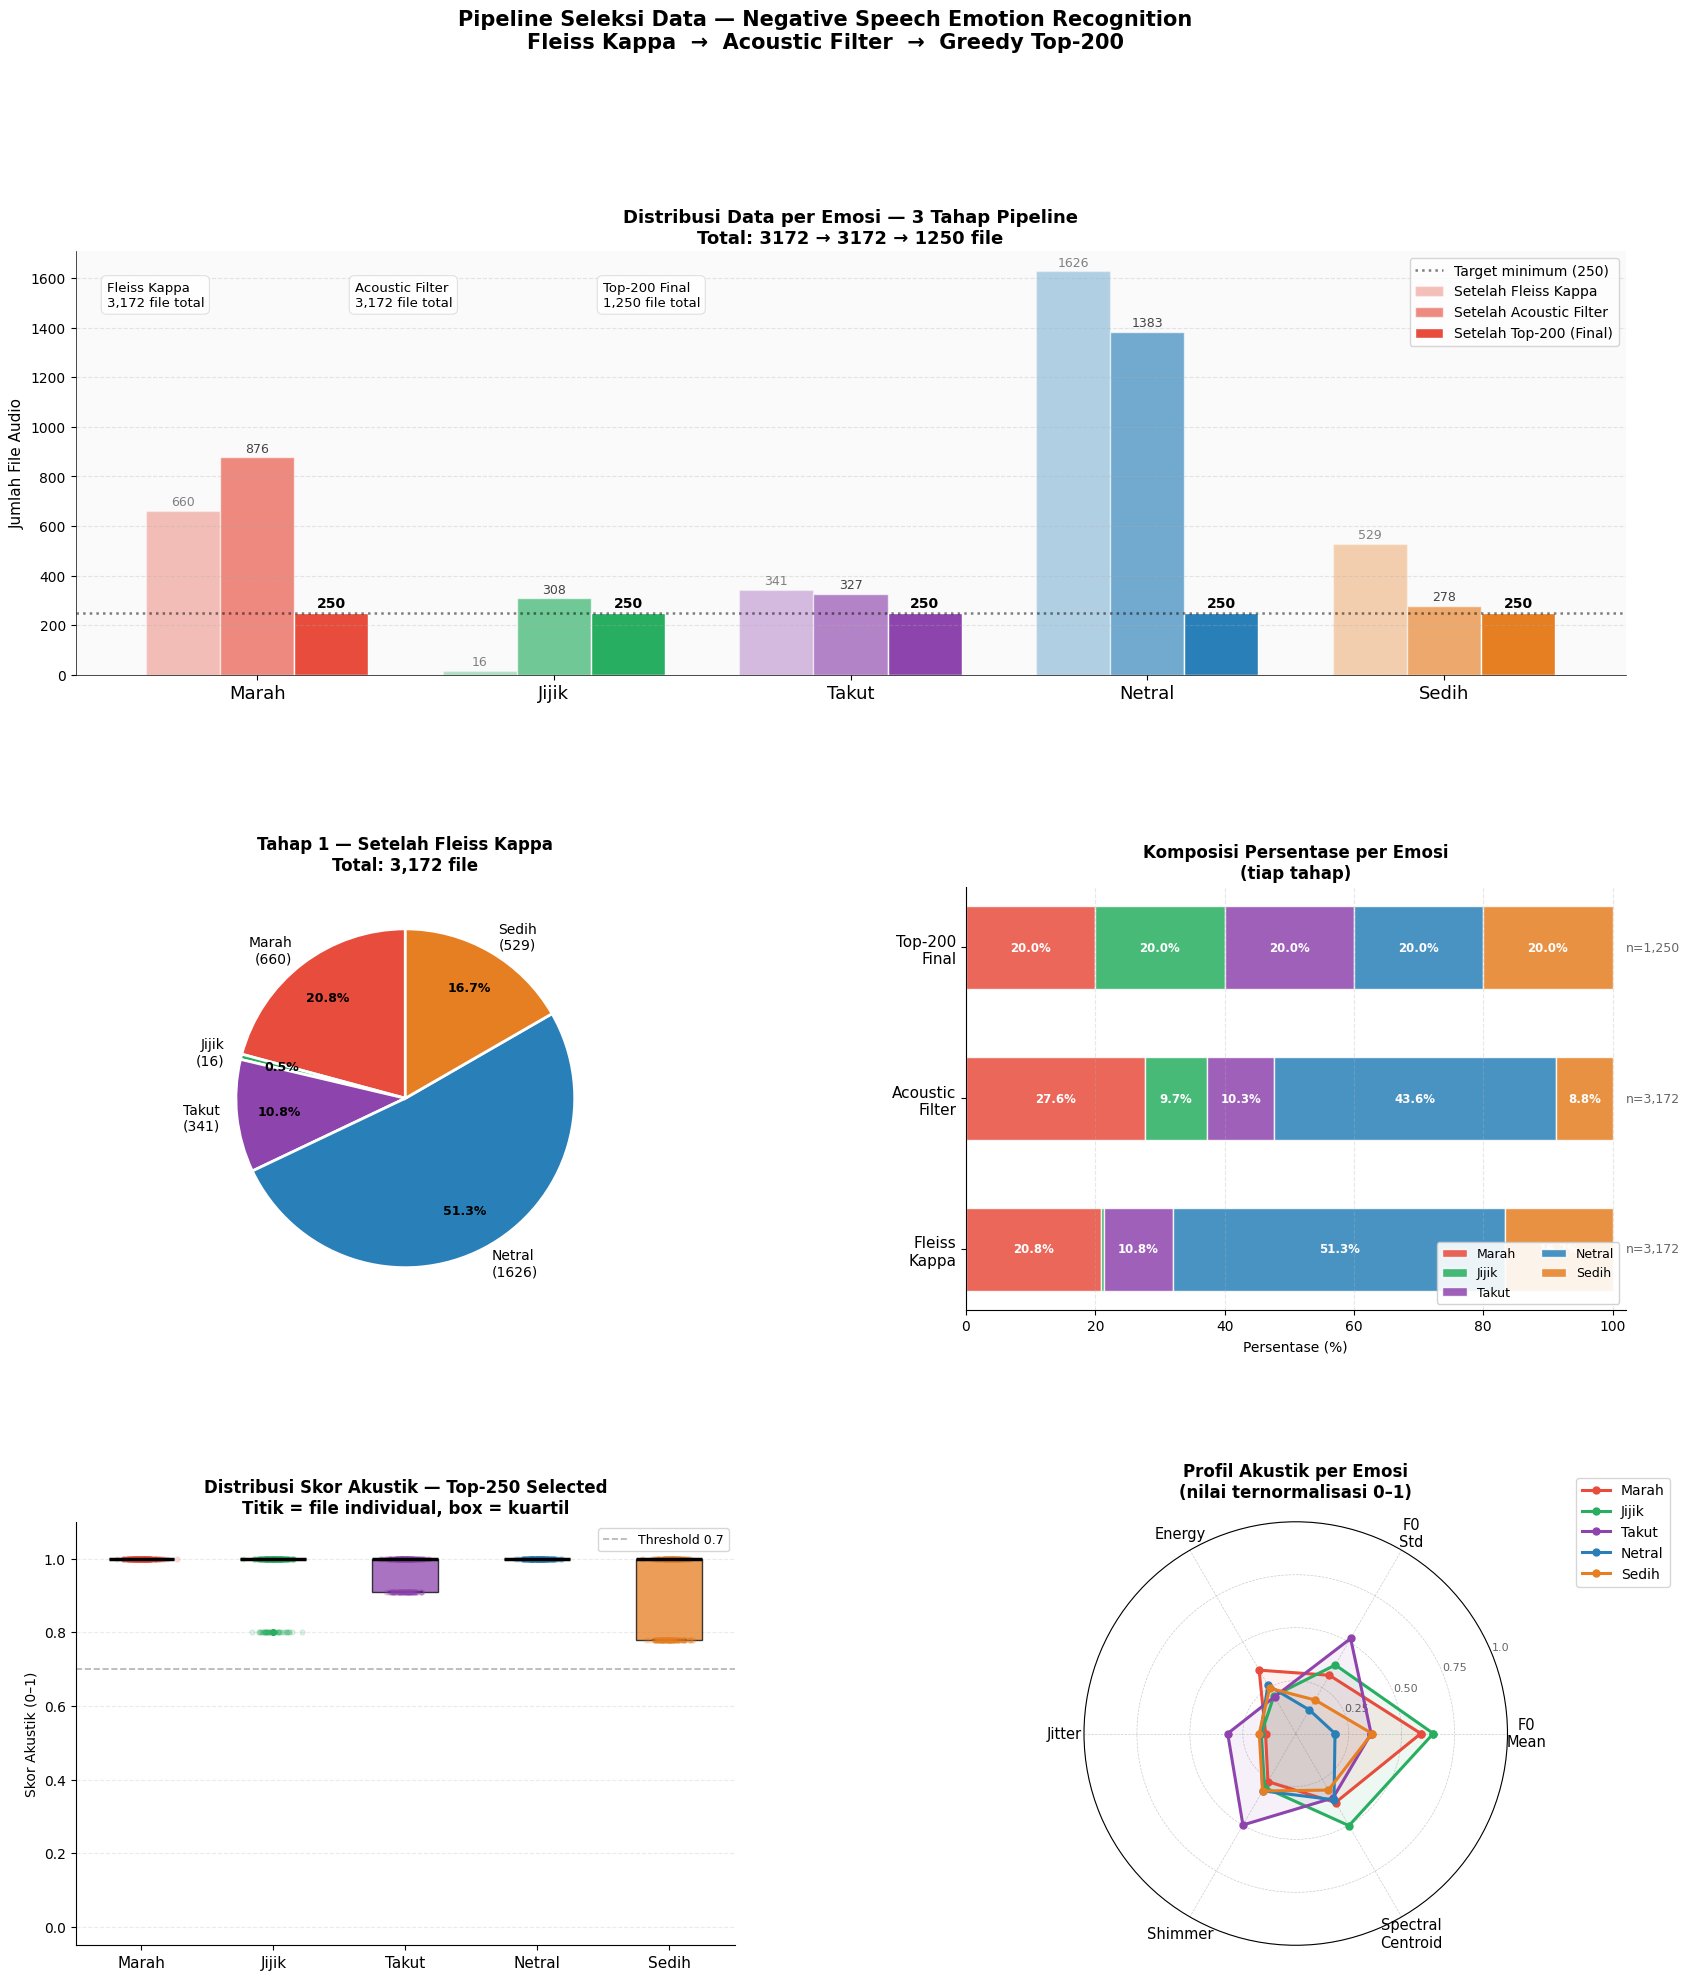

💾 Visualisasi → /content/drive/MyDrive/TADATA/Visualisasi/acoustic_filter_pipeline.png

📊 Ringkasan data:
   Fleiss Kappa    : 3,172 file
   Acoustic Filter : 3,172 file (setelah scoring)
   Top-200 Final   : 1,250 file (250 per kelas)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

EM_COLORS = {
    'Jijik':   '#27AE60',
    'Marah':   '#E74C3C',
    'Netral':  '#2980B9',
    'Sedih':   '#E67E22',
    'Takut':   '#8E44AD',
    'Bahagia': '#F1C40F',
}

# ── Hitung distribusi tiap tahap ──
# Tahap 1: Fleiss Kappa (label_asli dari scan)
fleiss = df[df['status'].isin(['OK','RELABEL'])].copy()
dist_fleiss = {em: (fleiss['label_asli']==em).sum()
               for em in VALID_EMOTIONS}
total_fleiss = sum(dist_fleiss.values())

# Tahap 2: Acoustic Filter (label_akustik dari scoring)
dist_filter = {em: (valid_df['label_akustik']==em).sum()
               for em in VALID_EMOTIONS}
total_filter = sum(dist_filter.values())

# Tahap 3: Top-N Greedy (label_final, N=TARGET)
dist_final = {em: (df_final['label_final']==em).sum()
              for em in VALID_EMOTIONS}
total_final = sum(dist_final.values())

print(f"Tahap 1 (Fleiss Kappa)    : {total_fleiss} file")
print(f"Tahap 2 (Acoustic Filter) : {total_filter} file")
print(f"Tahap 3 (Top-{TARGET} Greedy)  : {total_final} file")


# ── Layout: 3 baris × 2 kolom + row khusus summary ──
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Pipeline Seleksi Data — Negative Speech Emotion Recognition\n'
    f'Fleiss Kappa  →  Acoustic Filter  →  Greedy Top-{TARGET}',
    fontsize=15, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.50, wspace=0.35)


# ════════════════════════════════════════════════════════
#  BARIS 1: Perbandingan 3 tahap (grouped bar + summary)
# ════════════════════════════════════════════════════════

# ── Plot 1: Grouped bar 3 tahap ──
ax1 = fig.add_subplot(gs[0, :])   # full width

x  = np.arange(len(VALID_EMOTIONS))
w  = 0.25
ax1.set_facecolor('#FAFAFA')

b1 = ax1.bar(x - w,
             [dist_fleiss[em] for em in VALID_EMOTIONS],
             w, color=[EM_COLORS[em] for em in VALID_EMOTIONS],
             alpha=0.35, edgecolor='white', label='Setelah Fleiss Kappa')

b2 = ax1.bar(x,
             [dist_filter[em] for em in VALID_EMOTIONS],
             w, color=[EM_COLORS[em] for em in VALID_EMOTIONS],
             alpha=0.65, edgecolor='white', label='Setelah Acoustic Filter')

b3 = ax1.bar(x + w,
             [dist_final[em] for em in VALID_EMOTIONS],
             w, color=[EM_COLORS[em] for em in VALID_EMOTIONS],
             alpha=1.00, edgecolor='white', label=f'Setelah Top-{TARGET} (Final)')

# Anotasi angka
for bar, em in zip(b1, VALID_EMOTIONS):
    v = dist_fleiss[em]
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             str(v), ha='center', va='bottom', fontsize=9,
             color='gray', fontweight='normal')

for bar, em in zip(b2, VALID_EMOTIONS):
    v = dist_filter[em]
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             str(v), ha='center', va='bottom', fontsize=9,
             color='#444', fontweight='normal')

for bar, em in zip(b3, VALID_EMOTIONS):
    v = dist_final[em]
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             str(v), ha='center', va='bottom', fontsize=10,
             fontweight='bold', color='black')

ax1.axhline(TARGET, color='black', ls=':', lw=1.8,
            alpha=0.5, label=f'Target minimum ({TARGET})')
ax1.set_xticks(x)
ax1.set_xticklabels(VALID_EMOTIONS, fontsize=13)
ax1.set_ylabel('Jumlah File Audio', fontsize=11)
ax1.set_title(
    'Distribusi Data per Emosi — 3 Tahap Pipeline\n'
    f'Total: {total_fleiss} → {total_filter} → {total_final} file',
    fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.spines[['top','right']].set_visible(False)
ax1.spines['bottom'].set_linewidth(0.5)
ax1.spines['left'].set_linewidth(0.5)
ax1.grid(axis='y', alpha=0.3, ls='--', lw=0.8)

# Summary cards di dalam plot
for i, (label, total, alpha) in enumerate([
    ('Fleiss Kappa', total_fleiss, 0.35),
    ('Acoustic Filter', total_filter, 0.65),
    (f'Top-{TARGET} Final', total_final, 1.00),
]):
    ax1.annotate(
        f'{label}\n{total:,} file total',
        xy=(0.02 + i*0.16, 0.93),
        xycoords='axes fraction',
        fontsize=9.5, ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white', edgecolor='#DDD',
                  linewidth=0.8, alpha=0.9)
    )


# ════════════════════════════════════════════════════════
#  BARIS 2: Pie chart tiap tahap + Funnel reduksi
# ════════════════════════════════════════════════════════

# ── Plot 2a: Pie — Fleiss Kappa ──
ax2 = fig.add_subplot(gs[1, 0])
vals2  = [dist_fleiss[em] for em in VALID_EMOTIONS]
colors2= [EM_COLORS[em] for em in VALID_EMOTIONS]
wedges, texts, autotexts = ax2.pie(
    vals2,
    labels=[f"{em}\n({dist_fleiss[em]})" for em in VALID_EMOTIONS],
    colors=colors2,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':10}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax2.set_title(f'Tahap 1 — Setelah Fleiss Kappa\nTotal: {total_fleiss:,} file',
              fontsize=12, fontweight='bold', pad=12)


# ── Plot 2b: Horizontal bar — Perbandingan persentase ──
ax3 = fig.add_subplot(gs[1, 1])

stages = ['Fleiss\nKappa', 'Acoustic\nFilter', f'Top-{TARGET}\nFinal']
data_pct = {}
for em in VALID_EMOTIONS:
    data_pct[em] = [
        dist_fleiss[em] / total_fleiss * 100,
        dist_filter[em] / total_filter * 100,
        dist_final[em]  / total_final  * 100,
    ]

y_pos  = np.arange(len(stages))
bottom = np.zeros(len(stages))

for em in VALID_EMOTIONS:
    vals = np.array(data_pct[em])
    bars = ax3.barh(y_pos, vals, left=bottom,
                    color=EM_COLORS[em], alpha=0.85,
                    edgecolor='white', height=0.55, label=em)
    # Label persentase
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax3.text(b + v/2, i, f'{v:.1f}%',
                     ha='center', va='center',
                     fontsize=8.5, fontweight='bold', color='white')
    bottom += vals

ax3.set_yticks(y_pos)
ax3.set_yticklabels(stages, fontsize=11)
ax3.set_xlabel('Persentase (%)', fontsize=10)
ax3.set_xlim(0, 102)
ax3.set_title('Komposisi Persentase per Emosi\n(tiap tahap)',
              fontsize=12, fontweight='bold')
ax3.legend(loc='lower right', fontsize=9,
           framealpha=0.9, ncol=2)
ax3.spines[['top','right']].set_visible(False)
ax3.grid(axis='x', alpha=0.3, ls='--', lw=0.8)

# Anotasi keseimbangan
for i, (total, label) in enumerate(zip(
        [total_fleiss, total_filter, total_final],
        stages)):
    ax3.text(102, i, f'n={total:,}',
             va='center', ha='left', fontsize=9, color='#666')


# ════════════════════════════════════════════════════════
#  BARIS 3: Boxplot skor + Radar profil
# ════════════════════════════════════════════════════════

# ── Plot 3a: Boxplot distribusi skor per emosi ──
ax4 = fig.add_subplot(gs[2, 0])
score_data  = []
score_labels= []
bp_colors   = []
for em in VALID_EMOTIONS:
    sub = df_final[df_final['label_final']==em]
    sc  = f'skor_{em}'
    score_data.append(sub[sc].dropna().values)
    score_labels.append(em)
    bp_colors.append(EM_COLORS[em])

bp = ax4.boxplot(score_data, patch_artist=True, notch=False,
                 showfliers=True,
                 flierprops=dict(marker='o', markersize=3,
                                 alpha=0.4, linestyle='none'),
                 medianprops=dict(color='black', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2))
for patch, c in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
for flier, c in zip(bp['fliers'], bp_colors):
    flier.set(markerfacecolor=c, markeredgecolor=c)

# Tambah swarm-like jitter untuk visualisasi lebih kaya
for i, (data, c) in enumerate(zip(score_data, bp_colors), start=1):
    jitter = np.random.normal(i, 0.07, size=len(data))
    ax4.scatter(jitter, data, alpha=0.15, s=12,
                color=c, zorder=2)

ax4.set_xticks(range(1, len(VALID_EMOTIONS)+1))
ax4.set_xticklabels(VALID_EMOTIONS, fontsize=11)
ax4.set_ylabel('Skor Akustik (0–1)')
ax4.set_ylim(-0.05, 1.1)
ax4.axhline(0.7, color='gray', ls='--', lw=1.2,
            alpha=0.6, label='Threshold 0.7')
ax4.set_title(f'Distribusi Skor Akustik — Top-{TARGET} Selected\n'
              'Titik = file individual, box = kuartil',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.spines[['top','right']].set_visible(False)
ax4.grid(axis='y', alpha=0.25, ls='--', lw=0.8)

# ── Plot 3b: Radar chart profil akustik ──
ax5 = fig.add_subplot(gs[2, 1], polar=True)
feat_radar = ['f0_mean','f0_std','energy_rms',
              'jitter','shimmer','spectral_centroid']
feat_label = ['F0\nMean','F0\nStd','Energy',
              'Jitter','Shimmer','Spectral\nCentroid']
N      = len(feat_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for em in VALID_EMOTIONS:
    sub  = df_final[df_final['label_final']==em]
    vals = []
    for f in feat_radar:
        col = sub[f].dropna()
        mn  = df_final[f].min()
        mx  = df_final[f].max()
        vals.append((col.mean() - mn) / (mx - mn + 1e-9))
    vals += vals[:1]
    ax5.plot(angles, vals, 'o-', lw=2.2,
             color=EM_COLORS[em], label=em, markersize=5)
    ax5.fill(angles, vals, alpha=0.08, color=EM_COLORS[em])

ax5.set_xticks(angles[:-1])
ax5.set_xticklabels(feat_label, fontsize=10.5)
ax5.set_ylim(0, 1)
ax5.set_yticks([0.25, 0.5, 0.75, 1.0])
ax5.set_yticklabels(['0.25','0.50','0.75','1.0'],
                    fontsize=8, alpha=0.6)
ax5.set_title('Profil Akustik per Emosi\n(nilai ternormalisasi 0–1)',
              fontsize=12, fontweight='bold', pad=18)
ax5.legend(loc='upper right',
           bbox_to_anchor=(1.40, 1.12), fontsize=10)
ax5.grid(color='gray', ls='--', lw=0.5, alpha=0.4)

VIS_DIR = '/content/drive/MyDrive/TADATA/Visualisasi'
os.makedirs(VIS_DIR, exist_ok=True)
plt.savefig(os.path.join(VIS_DIR, 'acoustic_filter_pipeline.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"💾 Visualisasi → {VIS_DIR}/acoustic_filter_pipeline.png")
print(f"\n📊 Ringkasan data:")
print(f"   Fleiss Kappa    : {total_fleiss:,} file")
print(f"   Acoustic Filter : {total_filter:,} file (setelah scoring)")
print(f"   Top-{TARGET} Final   : {total_final:,} file ({TARGET} per kelas)")


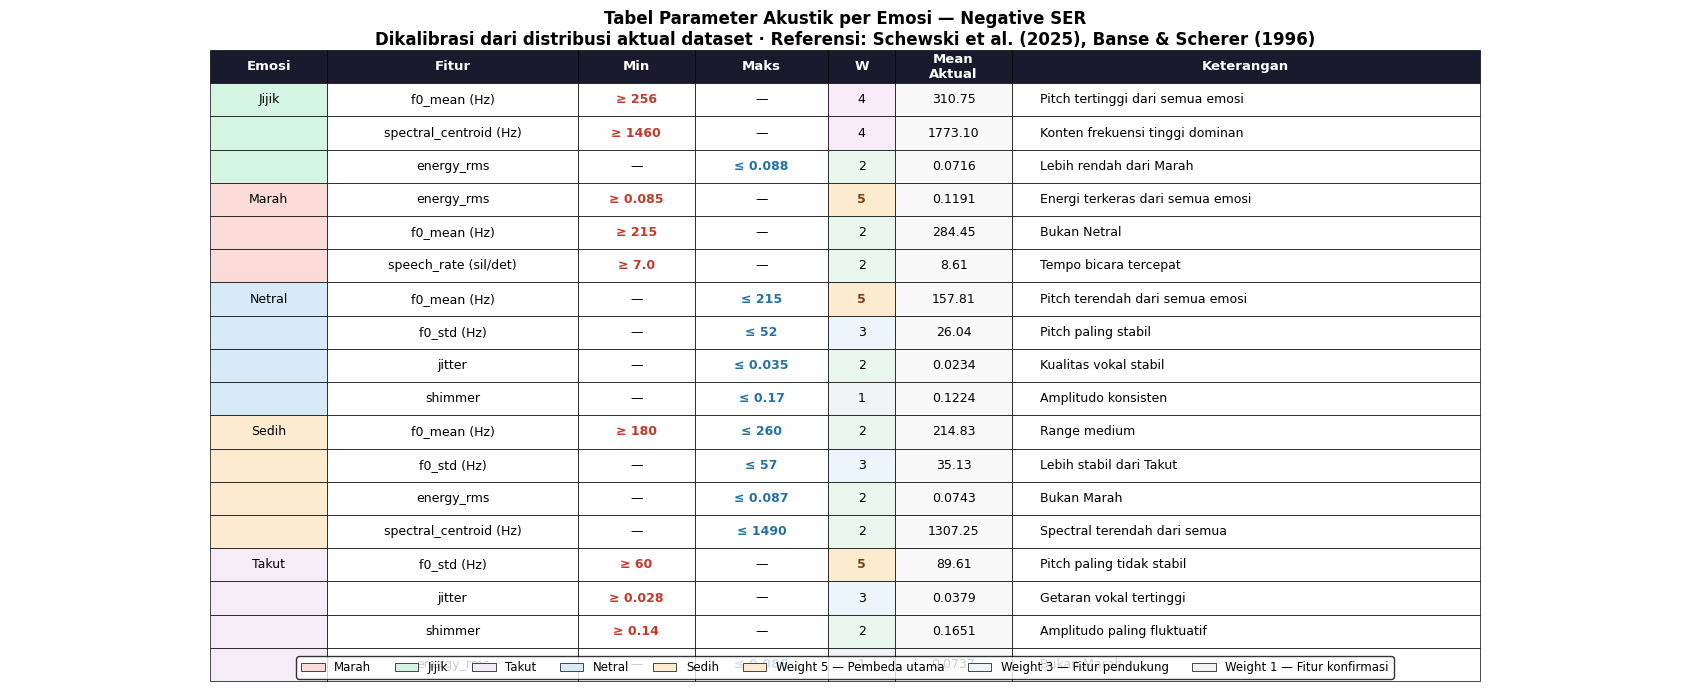

✅ Tabel A → /content/drive/MyDrive/TADATA/Visualisasi/tabel_parameter_emosi.png


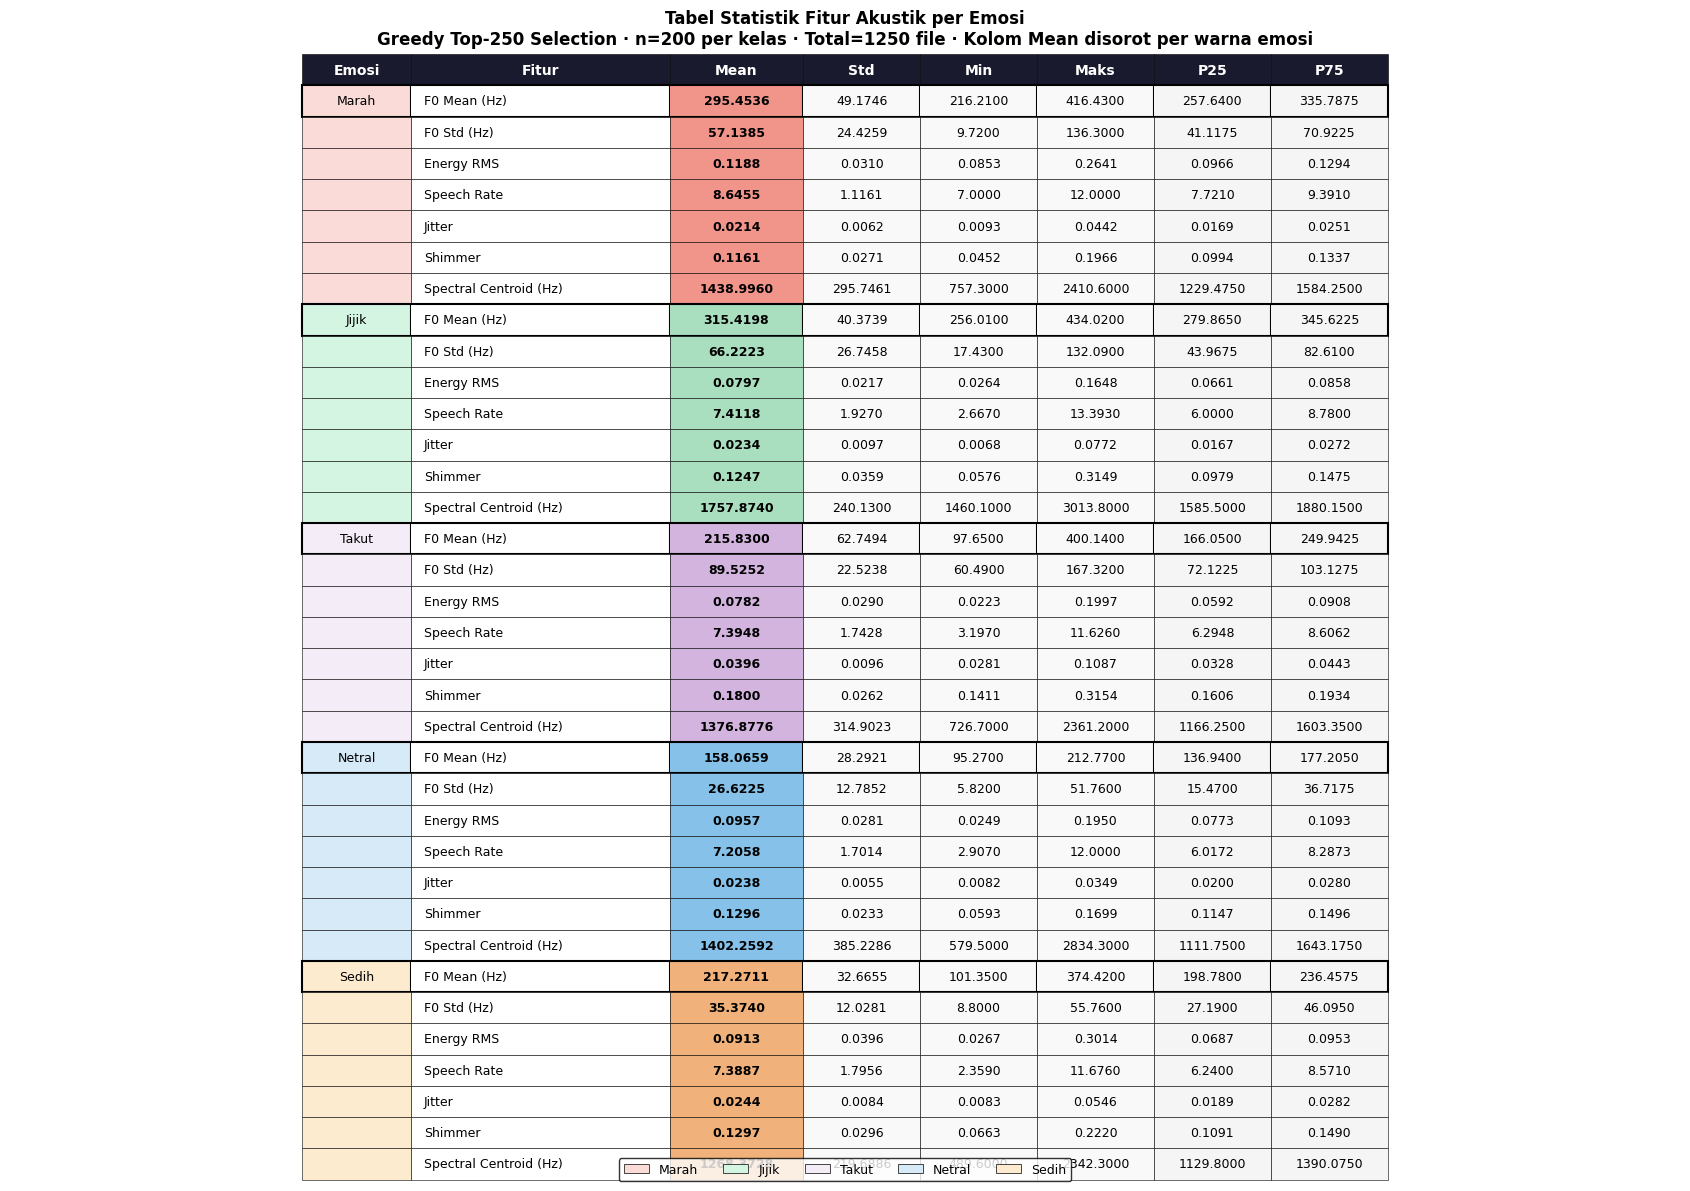

✅ Tabel B → /content/drive/MyDrive/TADATA/Visualisasi/tabel_statistik_emosi.png

📁 Semua output: /content/drive/MyDrive/TADATA/Visualisasi


In [ ]:
# ── CELL 12: Tabel Parameter & Statistik (Matplotlib) ────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

EM_COLORS_LIGHT = {
    'Jijik':   '#D5F5E3',
    'Marah':   '#FADBD8',
    'Netral':  '#D6EAF8',
    'Sedih':   '#FDEBD0',
    'Takut':   '#F4ECF7',
    'Bahagia': '#FCF3CF',
}
EM_COLORS_MID = {
    'Jijik':   '#A9DFBF',
    'Marah':   '#F1948A',
    'Netral':  '#85C1E9',
    'Sedih':   '#F0B27A',
    'Takut':   '#D2B4DE',
    'Bahagia': '#F9E79F',
}
W_COLORS = {5:'#FDEBD0', 4:'#F9EBF8', 3:'#EBF5FB', 2:'#E9F7EF', 1:'#F2F3F4'}

VIS_DIR = '/content/drive/MyDrive/TADATA/Visualisasi'
os.makedirs(VIS_DIR, exist_ok=True)


# ════════════════════════════════════════════════════════
#  TABEL A — Parameter Threshold per Emosi
# ════════════════════════════════════════════════════════

params_data = [
    # (emosi, fitur, min, maks, weight, mean_aktual, keterangan)
    ('Bahagia','f0_mean (Hz)',           '≥ 220',  '—',      4, '301.99', 'Nada tinggi, mendekati Marah'),
    ('Bahagia','f0_std (Hz)',            '≥ 55',   '—',      4, '76.37',  'Variasi nada lebar (mirip Takut)'),
    ('Bahagia','speech_rate (sil/det)',  '≥ 6.5',  '—',      3, '8.37',   'Tempo cepat, mirip Marah'),
    ('Bahagia','spectral_centroid (Hz)', '≥ 1500', '—',      2, '1589.42','Spektrum cerah'),
    ('Bahagia','jitter',                 '—',      '≤ 0.030',2, '0.0227', 'Suara mantap, pembeda dr Takut'),
    ('Jijik',  'f0_mean (Hz)',           '≥ 256',  '—',      4, '310.75', 'Pitch tertinggi dari semua emosi'),
    ('Jijik',  'spectral_centroid (Hz)', '≥ 1460', '—',      4, '1773.10','Konten frekuensi tinggi dominan'),
    ('Jijik',  'energy_rms',             '—',      '≤ 0.088',2, '0.0716', 'Lebih rendah dari Marah'),
    ('Marah',  'energy_rms',             '≥ 0.085','—',      5, '0.1191', 'Energi terkeras dari semua emosi'),
    ('Marah',  'f0_mean (Hz)',           '≥ 215',  '—',      2, '284.45', 'Bukan Netral'),
    ('Marah',  'speech_rate (sil/det)',  '≥ 7.0',  '—',      2, '8.61',   'Tempo bicara tercepat'),
    ('Netral', 'f0_mean (Hz)',           '—',      '≤ 215',  5, '157.81', 'Pitch terendah dari semua emosi'),
    ('Netral', 'f0_std (Hz)',            '—',      '≤ 52',   3, '26.04',  'Pitch paling stabil'),
    ('Netral', 'jitter',                 '—',      '≤ 0.035',2, '0.0234', 'Kualitas vokal stabil'),
    ('Netral', 'shimmer',                '—',      '≤ 0.17', 1, '0.1224', 'Amplitudo konsisten'),
    ('Sedih',  'f0_mean (Hz)',           '≥ 180',  '≤ 260',  2, '214.83', 'Range medium'),
    ('Sedih',  'f0_std (Hz)',            '—',      '≤ 57',   3, '35.13',  'Lebih stabil dari Takut'),
    ('Sedih',  'energy_rms',             '—',      '≤ 0.087',2, '0.0743', 'Bukan Marah'),
    ('Sedih',  'spectral_centroid (Hz)', '—',      '≤ 1490', 2, '1307.25','Spectral terendah dari semua'),
    ('Takut',  'f0_std (Hz)',            '≥ 60',   '—',      5, '89.61',  'Pitch paling tidak stabil'),
    ('Takut',  'jitter',                 '≥ 0.028','—',      3, '0.0379', 'Getaran vokal tertinggi'),
    ('Takut',  'shimmer',                '≥ 0.14', '—',      2, '0.1651', 'Amplitudo paling fluktuatif'),
    ('Takut',  'energy_rms',             '—',      '≤ 0.086',1, '0.0737', 'Bukan Marah'),
]

col_labels_A = ['Emosi','Fitur','Min','Maks','W','Mean\nAktual','Keterangan']
col_widths_A = [0.07, 0.15, 0.07, 0.08, 0.04, 0.07, 0.28]

fig_a, ax_a = plt.subplots(figsize=(17, 9.5))
ax_a.axis('off')
fig_a.patch.set_facecolor('white')

cell_text_a   = []
cell_colors_a = []
prev_em = None
for em, fitur, mn, mx, w, mean_val, ket in params_data:
    em_disp = em if em != prev_em else ''
    prev_em = em
    cell_text_a.append([em_disp, fitur, mn, mx, str(w), mean_val, ket])
    em_bg  = EM_COLORS_LIGHT[em]
    w_bg   = W_COLORS[w]
    cell_colors_a.append([em_bg, 'white', 'white', 'white',
                          w_bg, '#F9F9F9', 'white'])

tbl_a = ax_a.table(
    cellText=cell_text_a,
    colLabels=col_labels_A,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors_a,
    colWidths=col_widths_A,
)
tbl_a.auto_set_font_size(False)
tbl_a.set_fontsize(9)
tbl_a.scale(1, 1.75)

for (r, c), cell in tbl_a.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)
    if r == 0:
        cell.set_facecolor('#1A1A2E')
        cell.set_text_props(color='white', fontweight='bold', fontsize=9.5)
    if c == 6 and r > 0:
        cell.get_text().set_ha('left')
        cell.PAD = 0.06
    if c == 2 and r > 0:
        t = cell.get_text().get_text()
        if t.startswith('≥'):
            cell.get_text().set_color('#C0392B')
            cell.get_text().set_fontweight('bold')
    if c == 3 and r > 0:
        t = cell.get_text().get_text()
        if t.startswith('≤'):
            cell.get_text().set_color('#2471A3')
            cell.get_text().set_fontweight('bold')
    if c == 4 and r > 0:
        t = cell.get_text().get_text()
        if t == '5':
            cell.get_text().set_fontweight('bold')
            cell.get_text().set_color('#784212')

# Legend weight
legend_items = [
    mpatches.Patch(facecolor=W_COLORS[5], edgecolor='black', linewidth=0.5,
                   label='Weight 5 — Pembeda utama'),
    mpatches.Patch(facecolor=W_COLORS[3], edgecolor='black', linewidth=0.5,
                   label='Weight 3 — Fitur pendukung'),
    mpatches.Patch(facecolor=W_COLORS[1], edgecolor='black', linewidth=0.5,
                   label='Weight 1 — Fitur konfirmasi'),
]
em_items = [
    mpatches.Patch(facecolor=EM_COLORS_LIGHT[em], edgecolor='black',
                   linewidth=0.5, label=em)
    for em in VALID_EMOTIONS
]
ax_a.legend(handles=em_items + legend_items,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.07),
            ncol=9, fontsize=8.5,
            frameon=True, edgecolor='black',
            facecolor='white')

ax_a.set_title(
    'Tabel Parameter Akustik per Emosi — Negative SER\n'
    'Dikalibrasi dari distribusi aktual dataset · '
    'Referensi: Schewski et al. (2025), Banse & Scherer (1996)',
    fontsize=12, fontweight='bold', pad=22, color='black')

plt.tight_layout()
path_a = os.path.join(VIS_DIR, 'tabel_parameter_emosi.png')
plt.savefig(path_a, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Tabel A → {path_a}")


# ════════════════════════════════════════════════════════
#  TABEL B — Statistik Fitur per Emosi
# ════════════════════════════════════════════════════════

feat_stat  = ['f0_mean','f0_std','energy_rms','speech_rate',
              'jitter','shimmer','spectral_centroid']
feat_names = ['F0 Mean (Hz)','F0 Std (Hz)','Energy RMS',
              'Speech Rate','Jitter','Shimmer','Spectral Centroid (Hz)']

col_labels_B = ['Emosi','Fitur','Mean','Std','Min','Maks','P25','P75']
col_widths_B = [0.065, 0.155, 0.08, 0.07, 0.07, 0.07, 0.07, 0.07]

cell_text_b   = []
cell_colors_b = []

for em in VALID_EMOTIONS:
    sub     = df_final[df_final['label_final']==em]
    em_bg   = EM_COLORS_LIGHT[em]
    em_bg_m = EM_COLORS_MID[em]

    for idx, (f, fn) in enumerate(zip(feat_stat, feat_names)):
        vals  = sub[f].dropna()
        mean_ = f'{vals.mean():.4f}'
        std_  = f'{vals.std():.4f}'
        min_  = f'{vals.min():.4f}'
        max_  = f'{vals.max():.4f}'
        p25_  = f'{np.percentile(vals,25):.4f}'
        p75_  = f'{np.percentile(vals,75):.4f}'

        em_disp = em if idx == 0 else ''
        cell_text_b.append([em_disp, fn, mean_, std_,
                            min_, max_, p25_, p75_])

        # Mean kolom diberi warna lebih terang dari baris emosi
        row_colors = [em_bg, 'white', em_bg_m,
                      '#F9F9F9','#F9F9F9','#F9F9F9',
                      '#F5F5F5','#F5F5F5']
        cell_colors_b.append(row_colors)

fig_b, ax_b = plt.subplots(figsize=(17, 15))
ax_b.axis('off')
fig_b.patch.set_facecolor('white')

tbl_b = ax_b.table(
    cellText=cell_text_b,
    colLabels=col_labels_B,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors_b,
    colWidths=col_widths_B,
)
tbl_b.auto_set_font_size(False)
tbl_b.set_fontsize(9)
tbl_b.scale(1, 1.55)

for (r, c), cell in tbl_b.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(0.4)
    if r == 0:
        cell.set_facecolor('#1A1A2E')
        cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    if c == 2 and r > 0:
        cell.get_text().set_fontweight('bold')
    if c == 1 and r > 0:
        cell.get_text().set_ha('left')
        cell.PAD = 0.05

# Garis pemisah tebal antar emosi
n_feat = len(feat_stat)
for i, em in enumerate(VALID_EMOTIONS):
    start_row = 1 + i * n_feat
    end_row   = start_row + n_feat - 1
    # Batas atas tiap grup emosi
    for c in range(len(col_labels_B)):
        tbl_b[start_row, c].set_linewidth(1.5)
        tbl_b[start_row, c].visible_edges = 'TBLR' if c == 0 else 'TBR'

# Legend emosi
em_legend = [
    mpatches.Patch(facecolor=EM_COLORS_LIGHT[em],
                   edgecolor='black', linewidth=0.5, label=em)
    for em in VALID_EMOTIONS
]
ax_b.legend(handles=em_legend,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.035),
            ncol=6, fontsize=9,
            frameon=True, edgecolor='black',
            facecolor='white')

ax_b.set_title(
    'Tabel Statistik Fitur Akustik per Emosi\n'
    f'Greedy Top-{TARGET} Selection · n={TARGET} per kelas · Total={len(df_final)} file · '
    'Kolom Mean disorot per warna emosi',
    fontsize=12, fontweight='bold', pad=22, color='black')

plt.tight_layout()
path_b = os.path.join(VIS_DIR, 'tabel_statistik_emosi.png')
plt.savefig(path_b, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Tabel B → {path_b}")
print(f"\n📁 Semua output: {VIS_DIR}")

In [ ]:
# ── DAFTAR NAMA FILE WAV PER EMOSI (folder BigData_Filtered) ──────
# Membaca langsung dari struktur folder OUTPUT_ROOT/{emosi}/*.wav
# hasil reorganize_files(), bukan dari df_final — supaya jadi
# pengecekan independen: apakah file fisik di folder benar2 cocok
# dengan yang seharusnya ada menurut df_final.

print("\n" + "="*60)
print("DAFTAR FILE WAV PER EMOSI — BigData_Filtered")
print("="*60)

file_lists = {}
for em in VALID_EMOTIONS:
    folder = os.path.join(OUTPUT_ROOT, em)
    if os.path.isdir(folder):
        files = sorted([f for f in os.listdir(folder) if f.lower().endswith('.wav')])
    else:
        files = []
    file_lists[em] = files

    print(f"\n📂 {em}  ({len(files)} file .wav)")
    for fname in files[:5]:
        print(f"   - {fname}")
    if len(files) > 5:
        print(f"   ... dan {len(files) - 5} file lainnya")

total_files = sum(len(v) for v in file_lists.values())
print(f"\n{'='*60}")
print(f"Total seluruh file .wav : {total_files}")
print(f"{'='*60}")

# ── Cek konsistensi: jumlah file fisik vs TARGET ──
print("\nKonsistensi jumlah file vs TARGET:")
for em in VALID_EMOTIONS:
    n    = len(file_lists[em])
    flag = "✅" if n == TARGET else "⚠️ "
    print(f"   {flag} {em:<8}: {n:>4} file  (target: {TARGET})")

# ── Simpan daftar lengkap ke CSV untuk referensi/lampiran ──
list_records = [{'label': em, 'filename': fname}
                 for em, files in file_lists.items() for fname in files]
df_filelist  = pd.DataFrame(list_records)
LIST_CSV     = os.path.join(OUTPUT_ROOT, 'daftar_file_per_emosi.csv')
df_filelist.to_csv(LIST_CSV, index=False)
print(f"\n💾 Daftar lengkap ({len(df_filelist)} baris) disimpan → {LIST_CSV}")
